<a href="https://colab.research.google.com/github/FNT138/Analisis_PrediccionIncendiosForestales/blob/main/Clase2_Ejemplos_Spiegelhalter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PEPA 2026: Datos Reales de "El Arte de la Estadística"

Este Notebook descarga y analiza los datasets oficiales del libro de **David Spiegelhalter** directamente desde GitHub.

**Objetivo:** Trabajar con la evidencia real para entender la variabilidad y la probabilidad condicional.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

%matplotlib inline
plt.style.use('ggplot')

# 1. Dataset del Titanic (URL pública estándar y robusta)
URL_TITANIC = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# 2. URLs Raw de GitHub corregidas usando las carpetas reales del repo de Spiegelhalter
URL_BASE = "https://raw.githubusercontent.com/dspiegel29/ArtofStatistics/master/"
URL_HEART ="https://dspiegel29.github.io/ArtofStatistics/01-1-2-3-child-heart-survival-times/01-1-child-heart-survival-x.csv"
URL_TIPS = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

print("Librerías cargadas y rutas exactas preparadas.")

Librerías cargadas y rutas exactas preparadas.


## 1. Probabilidad Condicional en el Titanic

El dataset del Titanic es un clásico para entender que la probabilidad de un evento (sobrevivir) cambia drásticamente si condicionamos por otras variables (clase, sexo).

In [ ]:
try:
    df_titanic = pd.read_csv(URL_TITANIC)
    print("Primeras filas del dataset del Titanic:")
    display(df_titanic.head())
except Exception as e:
    print(f"Error cargando los datos: {e}")

Primeras filas del dataset del Titanic:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Calculamos la probabilidad global de supervivencia
if 'df_titanic' in locals():
    supervivientes = df_titanic['Survived'].sum()
    total = len(df_titanic)
    prob_global = supervivientes / total
    print(f"Probabilidad de supervivencia (Global): {prob_global:.2%} ({supervivientes}/{total})")

Probabilidad de supervivencia (Global): 38.38% (342/891)


In [ ]:
# P(Sobrevivir | Mujer)
if 'df_titanic' in locals():
    mujeres = df_titanic[df_titanic['Sex'] == 'female']
    prob_mujer = mujeres['Survived'].mean()
    print(f"P(Sobrevivir | Mujer): {prob_mujer:.2%}")

    # P(Sobrevivir | Hombre, 3ra Clase)
    hombres_3ra = df_titanic[(df_titanic['Sex'] == 'male') & (df_titanic['Pclass'] == 3)]
    prob_hombre_3ra = hombres_3ra['Survived'].mean()
    print(f"P(Sobrevivir | Hombre y 3ra Clase): {prob_hombre_3ra:.2%}")

P(Sobrevivir | Mujer): 74.20%
P(Sobrevivir | Hombre y 3ra Clase): 13.54%


## 2. Cirugía Cardíaca Infantil (El caso de Bristol)

Restauramos el análisis de los datos del hospital de Bristol que se había perdido. Vamos a graficar la tasa de mortalidad frente al volumen de operaciones.

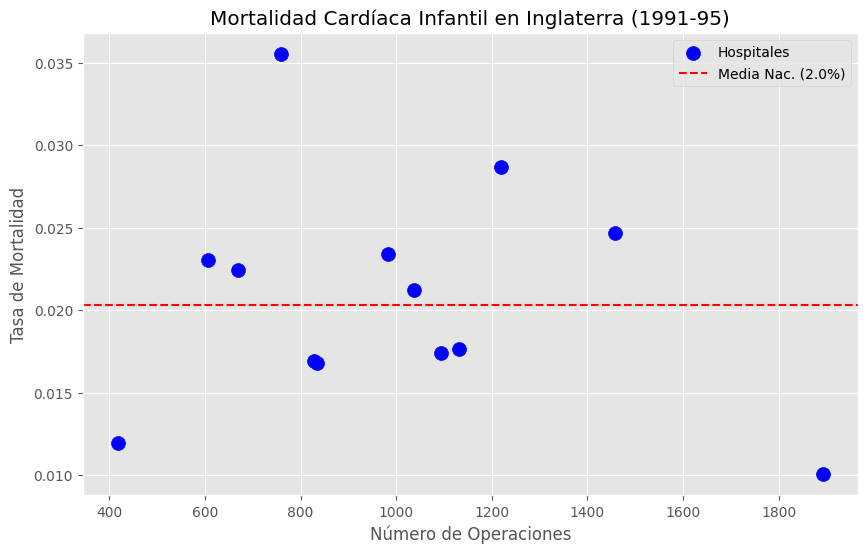

In [ ]:
try:
    df_heart = pd.read_csv(URL_HEART)

    # Identificar columnas independientemente del formato exacto del CSV
    col_ops = 'Operations' if 'Operations' in df_heart.columns else df_heart.columns[1]
    col_deaths = 'Deaths' if 'Deaths' in df_heart.columns else df_heart.columns[3]
    col_hosp = 'Hospital' if 'Hospital' in df_heart.columns else df_heart.columns[0]

    df_heart['Tasa_Mortalidad'] = df_heart[col_deaths] / df_heart[col_ops]
    tasa_nacional = df_heart[col_deaths].sum() / df_heart[col_ops].sum()

    plt.figure(figsize=(10, 6))
    plt.scatter(df_heart[col_ops], df_heart['Tasa_Mortalidad'], color='blue', s=100, label='Hospitales')
    plt.axhline(tasa_nacional, color='red', linestyle='--', label=f'Media Nac. ({tasa_nacional:.1%})')

    plt.title("Mortalidad Cardíaca Infantil en Inglaterra (1991-95)")
    plt.xlabel("Número de Operaciones")
    plt.ylabel("Tasa de Mortalidad")
    plt.legend()
    plt.show()
except Exception as e:
    print(f"Error al cargar los datos cardíacos: {e}")

## 3. El Mito de la Propina: ¿Dejamos realmente el 15%?
Existe una norma social (el \"mito\") que sugiere dejar un 15% o 20% de propina en los restaurantes. Pero, ¿qué hace la gente en la realidad?

Usaremos un dataset clásico para ver la distribución empírica, comparar la media con la mediana, y comprobar si nuestro comportamiento real se ajusta a esa etiqueta.


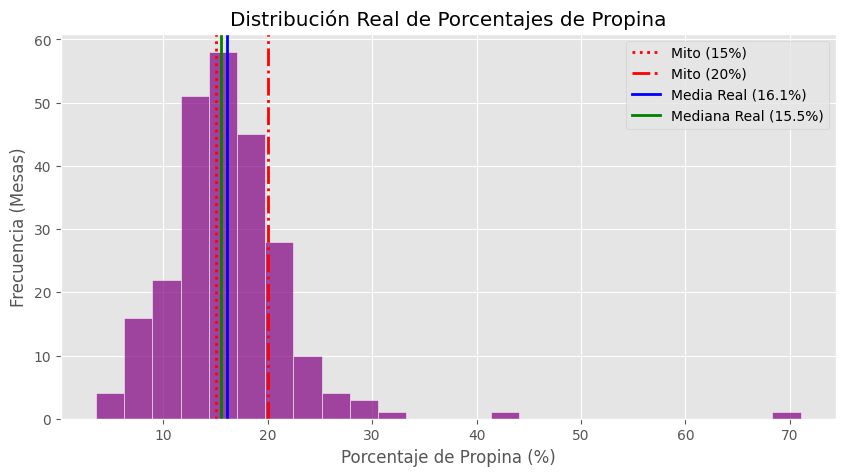

In [ ]:
try:
  df_tips = pd.read_csv(URL_TIPS)

            # Calculamos el porcentaje de propina por mesa
  df_tips['Tip_Percentage'] = (df_tips['tip'] / df_tips['total_bill']) * 100

  media_propina = df_tips['Tip_Percentage'].mean()
  mediana_propina = df_tips['Tip_Percentage'].median()

  plt.figure(figsize=(10, 5))
  plt.hist(df_tips['Tip_Percentage'], bins=25, color='purple', edgecolor='white', alpha=0.7)
  plt.axvline(15.0, color='red', linestyle=':', linewidth=2, label='Mito (15%)')
  plt.axvline(20.0, color='red', linestyle='-.', linewidth=2, label='Mito (20%)')
  plt.axvline(media_propina, color='blue', linewidth=2, label=f'Media Real ({media_propina:.1f}%)')
  plt.axvline(mediana_propina, color='green', linewidth=2, label=f'Mediana Real ({mediana_propina:.1f}%)')

  plt.title('Distribución Real de Porcentajes de Propina')
  plt.xlabel('Porcentaje de Propina (%)')
  plt.ylabel('Frecuencia (Mesas)')
  plt.legend()
  plt.show()
except Exception as e:
  print(f"Error cargando los datos de propinas: {e}")


## Media, Mediana, Error Absoluto (L1) y Error Cuadrático (L2)

### La Media (Promedio)

La media es la suma de todos los valores dividida por el número total de valores. Es sensible a los valores atípicos y representa el 'centro de gravedad' de una distribución.

**Propósito:** Representa el valor central o típico de un conjunto de datos.

**Fórmula:**
$$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i $$

### La Mediana

La mediana es el valor central en un conjunto de datos ordenado. Si el número de observaciones es impar, es el valor del medio; si es par, es el promedio de los dos valores del medio. Es robusta a los valores atípicos.

**Propósito:** Proporciona una medida de tendencia central que no se ve afectada por valores extremos.

**Cálculo:**
1. Ordena los datos de menor a mayor.
2. Si $n$ es impar, la mediana es el valor en la posición $(n+1)/2$.
3. Si $n$ es par, la mediana es el promedio de los valores en las posiciones $n/2$ y $(n/2)+1$.

### Error Absoluto (L1 Norm)

El error absoluto, o norma L1, mide la suma de las diferencias absolutas entre los puntos de datos y un valor de referencia (típicamente la mediana cuando se busca minimizar este error).

**Propósito:** Cuantificar la desviación promedio entre los puntos de datos y un punto central, siendo robusto a los valores atípicos.

**Fórmula (Minimización):** Para un valor `c` que minimiza la suma de errores absolutos:
$$ L_1(c) = \sum_{i=1}^{n} |x_i - c| $$
La **mediana** es el valor que minimiza la suma del error absoluto (L1).

### Error Cuadrático (L2 Norm)

El error cuadrático, o norma L2, mide la suma de los cuadrados de las diferencias entre los puntos de datos y un valor de referencia (típicamente la media cuando se busca minimizar este error).

**Propósito:** Cuantificar la varianza de los datos con respecto a un punto central, penalizando más las grandes desviaciones. Es sensible a los valores atípicos.

**Fórmula (Minimización):** Para un valor `c` que minimiza la suma de errores cuadráticos:
$$ L_2(c) = \sum_{i=1}^{n} (x_i - c)^2 $$
La **media** es el valor que minimiza la suma del error cuadrático (L2).

### Tarea para el Alumno:

Observa el plot interactivo a continuación. Intenta mover el deslizador (`c`) y comprueba visualmente cómo el **Error Absoluto (L1)** alcanza su valor mínimo cuando `c` se aproxima a la **Mediana** de los datos, y cómo el **Error Cuadrático (L2)** se minimiza cuando `c` se acerca a la **Media**.

In [ ]:
if 'df_tips' in locals():
    data = df_tips['Tip_Percentage'].dropna()

    # Calcular la media y la mediana de los datos de propina
    mean_tip = data.mean()
    median_tip = data.median()
    CmaximoooTip=data.max()*0+ 20*1

    # Definir las funciones para los errores L1 y L2
    def l1_error(c, data):
        return np.sum(np.abs(data - c))

    def l2_error(c, data):
        return np.sum((data - c)**2)

    # Definir la función interactiva para el plot
    def interactive_plot(c):
        l1_val = l1_error(c, data)
        l2_val = l2_error(c, data)

        # Crear un rango de valores para c para graficar las curvas de error
        c_range = np.linspace(data.min() - 5, CmaximoooTip + 5, 200)
        l1_curve = [l1_error(val, data) for val in c_range]
        l2_curve = [l2_error(val, data) for val in c_range]

        fig, ax1 = plt.subplots(figsize=(12, 6))

        color = 'tab:red'
        ax1.set_xlabel('Valor de c (porcentaje de propina)')
        ax1.set_ylabel('Error L1 (Suma de errores absolutos)', color=color)
        ax1.plot(c_range, l1_curve, color=color, label='Curva de Error L1')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.axvline(median_tip, color='red', linestyle='--', label=f'Mediana ({median_tip:.2f}%)')
        ax1.plot(c, l1_val, 'ro', markersize=8, label=f'L1 actual ({l1_val:.2f})')

        ax2 = ax1.twinx()  # instanciar un segundo eje que comparte el mismo eje x

        color = 'tab:blue'
        ax2.set_ylabel('Error L2 (Suma de errores cuadráticos)', color=color)
        ax2.plot(c_range, l2_curve, color=color, label='Curva de Error L2')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.axvline(mean_tip, color='blue', linestyle='--', label=f'Media ({mean_tip:.2f}%)')
        ax2.plot(c, l2_val, 'bo', markersize=8, label=f'L2 actual ({l2_val:.2f})')

        plt.title('Minimización de Errores L1 y L2 en función de c')
        fig.tight_layout()  # para que no se superpongan los labels

        # Combina las leyendas de ambos ejes
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4)

        plt.show()

    # Crear el slider interactivo
    interact(interactive_plot, c=widgets.FloatSlider(min=data.min(), max=CmaximoooTip, step=0.1, value=mean_tip, description='Valor de c'));
else:
    print("El DataFrame 'df_tips' no está disponible. Asegúrate de que la celda anterior haya sido ejecutada.")

interactive(children=(FloatSlider(value=16.08025817225047, description='Valor de c', max=20.0, min=3.563813585…

### Dataset Sintético con Outlier

Para visualizar de manera más dramática cómo los *outliers* afectan la media y la mediana, y consecuentemente la minimización de los errores L1 y L2, crearemos un dataset sintético con la mayoría de los puntos agrupados y un valor extremo.

In [ ]:
valorDExtremo = 300
np.random.seed(42)
synthetic_data = np.concatenate([np.random.normal(loc=15, scale=2, size=50), [valorDExtremo]])
data = pd.Series(synthetic_data) # Sobrescribimos 'data' con el nuevo dataset sintético

### Visualización del Dataset Sintético

Antes de interactuar con las curvas de error, veamos la distribución de nuestro dataset sintético, incluyendo el *outlier* que hemos añadido.

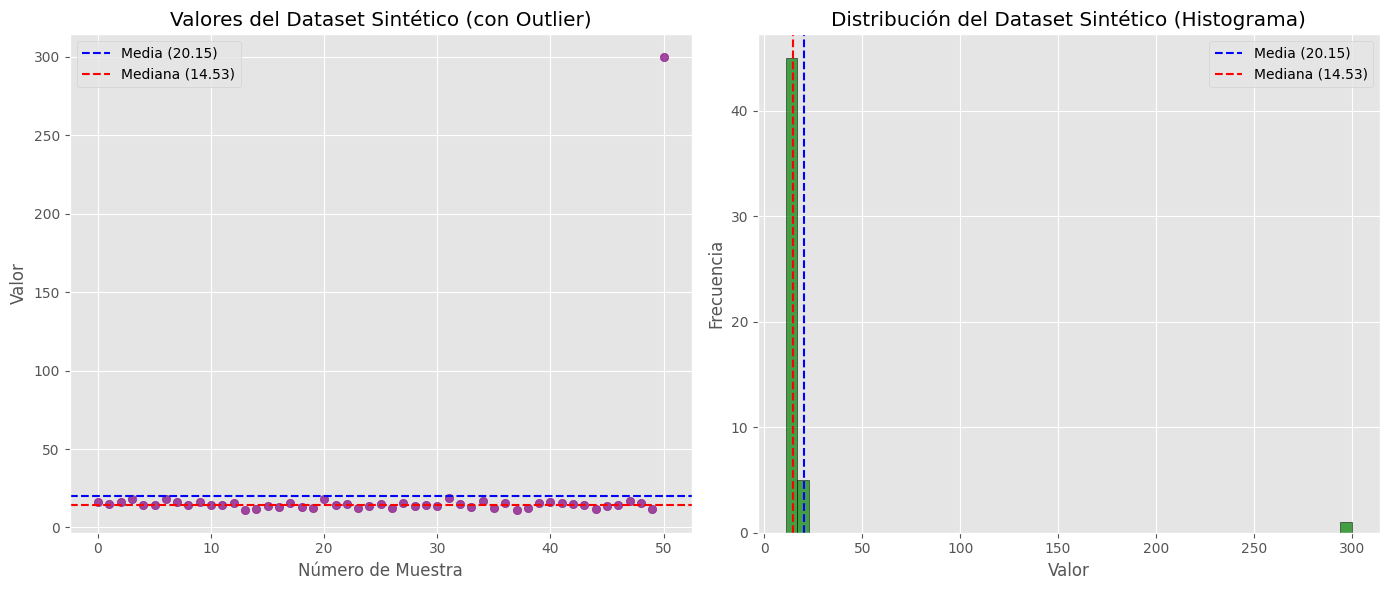

In [ ]:
if 'data' in locals():
    plt.figure(figsize=(14, 6))

    # Subplot 1: Scatter plot de los datos
    plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer plot
    plt.scatter(data.index, data, color='purple', alpha=0.7)
    plt.axhline(data.mean(), color='blue', linestyle='--', label=f'Media ({data.mean():.2f})')
    plt.axhline(data.median(), color='red', linestyle='--', label=f'Mediana ({data.median():.2f})')
    plt.title('Valores del Dataset Sintético (con Outlier)')
    plt.xlabel('Número de Muestra')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Histograma de los datos
    plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo plot
    plt.hist(data, bins=50, color='green', edgecolor='black', alpha=0.7)
    plt.axvline(data.mean(), color='blue', linestyle='--', label=f'Media ({data.mean():.2f})')
    plt.axvline(data.median(), color='red', linestyle='--', label=f'Mediana ({data.median():.2f})')
    plt.title('Distribución del Dataset Sintético (Histograma)')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("La variable 'data' no está disponible. Asegúrate de que la celda para generar el dataset sintético haya sido ejecutada.")

In [ ]:
if 'data' in locals():
    # Calcular la media y la mediana de los datos de propina (ahora el dataset sintético)
    mean_tip = data.mean()
    median_tip = data.median()
    maximooo=49

    # Definir las funciones para los errores L1 y L2
    def l1_error(c, data):
        return np.sum(np.abs(data - c))

    def l2_error(c, data):
        return np.sum((data - c)**2)

    # Definir la función interactiva para el plot
    def interactive_plot(c):
        l1_val = l1_error(c, data)
        l2_val = l2_error(c, data)

        # Crear un rango de valores para c para graficar las curvas de error
        c_range = np.linspace(data.min() - 5, maximooo + 5, 200)
        l1_curve = [l1_error(val, data) for val in c_range]
        l2_curve = [l2_error(val, data) for val in c_range]

        fig, ax1 = plt.subplots(figsize=(12, 6))

        color = 'tab:red'
        ax1.set_xlabel('Valor de c (valor del dataset)')
        ax1.set_ylabel('Error L1 (Suma de errores absolutos)', color=color)
        ax1.plot(c_range, l1_curve, color=color, label='Curva de Error L1')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.axvline(median_tip, color='red', linestyle='--', label=f'Mediana ({median_tip:.2f})')
        ax1.plot(c, l1_val, 'ro', markersize=8, label=f'L1 actual ({l1_val:.2f})')

        ax2 = ax1.twinx()  # instanciar un segundo eje que comparte el mismo eje x

        color = 'tab:blue'
        ax2.set_ylabel('Error L2 (Suma de errores cuadráticos)', color=color)
        ax2.plot(c_range, l2_curve, color=color, label='Curva de Error L2')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.axvline(mean_tip, color='blue', linestyle='--', label=f'Media ({mean_tip:.2f})')
        ax2.plot(c, l2_val, 'bo', markersize=8, label=f'L2 actual ({l2_val:.2f})')

        plt.title('Minimización de Errores L1 y L2 en función de c (Dataset Sintético con Outlier)')
        fig.tight_layout()  # para que no se superpongan los labels

        # Combina las leyendas de ambos ejes
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4)

        plt.show()

    # Crear el slider interactivo
    interact(interactive_plot, c=widgets.FloatSlider(min=data.min(), max=maximooo, step=0.1, value=mean_tip, description='Valor de c'));
else:
    print("La variable 'data' no está disponible. Asegúrate de que la celda anterior para generar el dataset sintético haya sido ejecutada.")

interactive(children=(FloatSlider(value=20.14612959753698, description='Valor de c', max=49.0, min=11.08065975…

**EJERCICIO 0 — Demostración algebraica (papel y lápiz):**

Se la muestra original de $n$ elementos, $\{x_i\}$, y las definiciones de la media muestral  $$\bar{x} = \frac{1}{n}\sum x_i$$ y de la varianza muestral: $$s^2_x = \frac{1}{n-1}\sum(x_i - \bar{x})^2$$, demostrá usando únicamente álgebra elemental que para el conjunto muestra $\{y_i\}$ que surje de transformar linealmente los $x_i$ es decir con   $$y_i = a + b\,x_i$$ se cumple que:

1. $\bar{y} = a + b\bar{x}$
2. $s^2_y = b^2\, s^2_x$

*Sugerencia para (2):* Primero mostrá que la muestra transformada $y_i - \bar{y} = b(x_i - \bar{x})$, luego elevá al cuadrado y sumá.

Como paso intermedio útil para ambas demostraciones, demostrá también la siguiente identidad algebraica:

$$\sum_{i=1}^{n}(x_i - \bar{x})^2 = \sum_{i=1}^{n}x_i^2 - n\bar{x}^2$$

*Sugerencia:* Expandí el cuadrado $(x_i - \bar{x})^2$, distribuí la sumatoria término a término, y usá la definición de $\bar{x}$ para simplificar.

---

## 🧪 Ejercicios de Exploración

### Ejercicio 1: Probabilidad condicional en el Titanic — verlo con histogramas

Ya calculaste $P(\text{sobrevivir} \mid \text{mujer})$ y $P(\text{sobrevivir} \mid \text{hombre, 3ra clase})$. Ahora graficalo.

**Consigna:** Graficá las siguientes frecuencias relativas (no absolutas):

- La distribución de edad (`Age`) para sobrevivientes vs. no sobrevivientes, en dos histogramas superpuestos con transparencia.
- La tasa de supervivencia por clase (`Pclass`) y sexo (`Sex`) como barras agrupadas.

Respondé:

1. ¿La edad parece tan determinante como el sexo o la clase?
2. ¿Cuántas veces mayor es la tasa de supervivencia en la celda más alta vs. la más baja de la tabla Clase × Sexo?
3. Usando la definición de probabilidad condicional $P(A|B) = P(A \cap B)/P(B)$, verificá algebraicamente uno de los valores del gráfico de barras calculándolo a mano desde los conteos del dataset.

---

### Ejercicio 2: El mito de la propina — Media, Mediana y Transformaciones Lineales

Ya viste que la distribución real de propinas no se ajusta perfectamente al "mito" del 15% o 20%. Ahora explorá qué pasa cuando cambiamos la escala.

La teoría dice que para $y_i = a + b\, x_i$:
$$\bar{y} = a + b\bar{x} \qquad \text{y} \qquad s^2_y = b^2\, s^2_x$$

**Consigna:** Usando la columna `Tip_Percentage`, construí un widget con sliders para $a$ y $b$ que muestre en tiempo real los histogramas de $x_i$ e $y_i$ lado a lado, con $\bar{x}$, $s^2_x$, $\bar{y}$, $s^2_y$ y sus predicciones teóricas.

Respondé:

1. Usá $a=0$, $b=0.01$ para pasar de porcentaje a proporción. ¿Cambia la forma del histograma? ¿Y el centro?
2. ¿Qué efecto tiene $a$ sobre $s^2$? ¿Por qué tiene sentido?
3. ¿Qué pasa si $b < 0$? ¿Por qué $s^2_y$ no puede volverse negativo?
4. La mediana minimiza el error L1 que viste en las celdas anteriores. ¿Esa propiedad se preserva bajo una transformación lineal? Es decir: si $m$ es la mediana de $x_i$, ¿es $a + b\cdot m$ la mediana de $y_i$? Verificalo con el widget.